#### Instalación de las librerías necesarias para el taller

In [1]:
!pip install "numpy>=1.25.0,<2.0.0"
!pip install scikit-surprise
!pip install pandas
!pip install matplotlib
!pip install seaborn
!pip install pyarrow
!pip install fastparquet


[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [41]:
import os
import numpy as np
import pandas as pd
from surprise import Reader
from surprise import Dataset
from surprise.model_selection import train_test_split
from surprise import KNNBasic, KNNWithMeans
from surprise import accuracy
import random
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

#### Carga de los datos iniciales

* **rating.csv** desde rating.csv, con las columnas userId, movieId, rating y timestamp.
* **movie.csv** desde movie.csv, con las columnas movieId, title y genres.

**movie.csv:** contiene información sobre las películas, incluyendo su título y género. **rating.csv** contiene información sobre las calificaciones que los usuarios han dado a las películas, incluyendo el ID del usuario, el ID de la película, la calificación y la marca de tiempo de la calificación. La interacción entre usuarios e ítems se refleja en rating.csv, donde cada fila representa una calificación dada por un usuario a una película específica.

In [4]:
DATA_DIR = Path("")
ratings = pd.read_csv(
    DATA_DIR / "rating.csv",
    dtype={
        "userId": "int32",
        "movieId": "int32",
        "rating": "float32",
    },
    parse_dates=["timestamp"]
)

movies = pd.read_csv(
    DATA_DIR / "movie.csv",
    dtype={
        "movieId": "int32",
        "title": "string",
        "genres": "string",
    }
)

In [5]:
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
pd.set_option("display.max_columns", 100)

## 1. Conocimiento del dataset de trabajo
### El taller se trabaja sobre un conjunto de datos obtenido de un proveedor de películas en streaming.

### 1.1. Ubique los datos en MovieLens 20M Dataset. Allí encuentra la información técnica y práctica para el uso de los datos, así como los requerimientos para su uso.

### 1.2. Estudie el formato de los datos, en particular identifique la manera de identificar qué información refleja la interacción entre usuarios e ítems

#### Exploración inicial de los datos

##### Vista general y calidad de datos

* ¿Cuántos usuarios, ítems e interacciones hay?
* ¿Hay nulos, duplicados o ids inconsistentes?

In [28]:
print("ratings shape:", ratings.shape)
print("movies shape:", movies.shape)

display(ratings.head())
display(movies.head())
print(ratings.dtypes)

# Dataset general View
# How many records, users and movies?

print("Unique users:", ratings["userId"].nunique())
print("unique movies in ratings:", ratings["movieId"].nunique())
print("Unique movies in movies:", movies["movieId"].nunique())
print("Ratings range:", ratings["rating"].min(), "a", ratings["rating"].max())

# Quality validation
# Are there null values?
# Are there duplicated values?
# Ratings ids exist in movies?

print("Null values in ratings:")
print(ratings.isnull().sum(), "\n")

print("Null values in movies:")
print(movies.isnull().sum(), "\n")

print("Duplicates userId-movieId:", ratings.duplicated(subset=["userId", "movieId"]).sum())

movie_ids_missing = set(ratings["movieId"].unique()) - set(movies["movieId"].unique())
print("Ratings's movieId that are not preset in movies:", len(movie_ids_missing))

ratings shape: (20000263, 4)
movies shape: (27278, 3)


,userId,movieId,rating,timestamp
0,1,2,3.5,2005-04-02 23:53:47
1,1,29,3.5,2005-04-02 23:31:16
2,1,32,3.5,2005-04-02 23:33:39
3,1,47,3.5,2005-04-02 23:32:07
4,1,50,3.5,2005-04-02 23:29:40


,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


userId                int32
movieId               int32
rating              float32
timestamp    datetime64[us]
dtype: object
Unique users: 138493
unique movies in ratings: 26744
Unique movies in movies: 27278
Ratings range: 0.5 a 5.0
Null values in ratings:
userId       0
movieId      0
rating       0
timestamp    0
dtype: int64 

Null values in movies:
movieId    0
title      0
genres     0
dtype: int64 

Duplicates userId-movieId: 0
Ratings's movieId that are not preset in movies: 0


La validación inicial del dataset muestra que se trata de una fuente de datos limpia y consistente para tareas de recomendación. El conjunto contiene 138,493 usuarios, 26,744 películas con ratings y más de 20 millones de interacciones. La escala de calificación va de 0.5 a 5.0, lo que proporciona una señal explícita relativamente fina.

Desde el punto de vista de calidad de datos, no se encontraron valores nulos ni en la tabla de ratings ni en la tabla de películas. Tampoco se detectaron duplicados por la llave (userId, movieId), lo que garantiza que cada interacción usuario–película está registrada una sola vez. Además, todas las películas presentes en ratings existen en movies, por lo que no hay inconsistencias referenciales entre ambas tablas.

En consecuencia, el dataset se encuentra en condiciones adecuadas para análisis exploratorio y modelado colaborativo, y los principales desafíos del taller no estarán asociados a problemas de limpieza, sino a la estructura propia del problema de recomendación, como la sparsity y la concentración de interacciones en una fracción pequeña del catálogo.

##### Distribución global de ratings

* ¿Cómo se distribuyen las calificaciones?
* ¿Hay sesgo hacia ratings altos?
* ¿Qué tan variable es la señal explícita?

,count,pct
rating,,
0.5,239125,1.20
1.0,680732,3.40
1.5,279252,1.40
2.0,1430997,7.15
2.5,883398,4.42
3.0,4291193,21.46
3.5,2200156,11.00
4.0,5561926,27.81
4.5,1534824,7.67


count    2.000026e+07
mean     3.525529e+00
std      1.051989e+00
min      5.000000e-01
25%      3.000000e+00
50%      3.500000e+00
75%      4.000000e+00
max      5.000000e+00
Name: rating, dtype: float64

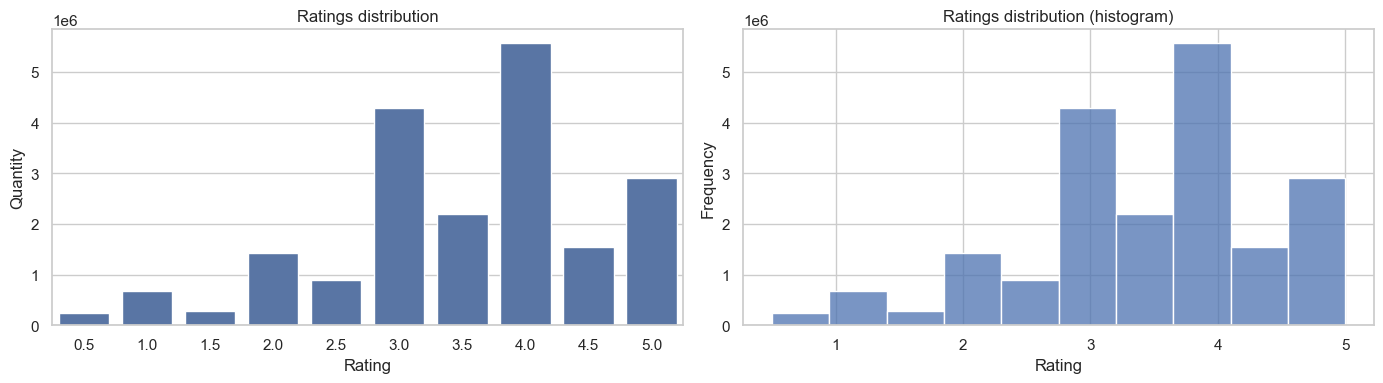

In [29]:
# Ratings distribution

# How are ratings distributed?
# Is there a bias to higher ratings?

rating_dist = ratings["rating"].value_counts().sort_index()
rating_pct = ratings["rating"].value_counts(normalize=True).sort_index() * 100

display(pd.DataFrame({
    "count": rating_dist,
    "pct": rating_pct.round(2)
}))

display(ratings["rating"].describe())

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.countplot(data=ratings, x="rating", order=sorted(ratings["rating"].unique()), ax=axes[0])
axes[0].set_title("Ratings distribution")
axes[0].set_xlabel("Rating")
axes[0].set_ylabel("Quantity")

sns.histplot(ratings["rating"], bins=len(sorted(ratings["rating"].unique())), kde=False, ax=axes[1])
axes[1].set_title("Ratings distribution (histogram)")
axes[1].set_xlabel("Rating")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

In [30]:
# Rating descriptive statistics
# What is the central distribution and spread of ratings?

print("Mean:", ratings["rating"].mean())
print("Median:", ratings["rating"].median())
print("Variance:", ratings["rating"].var())
print("Standard deviation:", ratings["rating"].std())

Mean: 3.5255287
Median: 3.5
Variance: 1.1066805
Standard deviation: 1.0519888


La distribución global de ratings muestra un sesgo claro hacia valores medios y altos. El rating más frecuente es 4.0 (27.81%), seguido por 3.0 (21.46%) y 5.0 (14.49%). En contraste, los ratings bajos tienen una participación mucho menor. La media (3.53) y la mediana (3.5) confirman que la tendencia central se ubica en la parte media-alta de la escala. Además, la varianza de 1.11 indica una dispersión moderada, lo que sugiere que los usuarios utilizan buena parte de la escala de calificación, aunque con predominio de evaluaciones favorables. En términos de recomendación, esto indica una señal explícita con sesgo positivo, lo que puede influir en la tendencia del modelo a predecir ratings altos y reduce la evidencia disponible sobre interacciones negativas.

##### Análisis de usuarios

* ¿Cómo es la distribución del número de ratings por usuario?
* ¿Cómo es la distribución del promedio de calificación por usuario?
* ¿Cómo se comporta la varianza por usuario?
* ¿Quiénes son los usuarios más activos?

In [31]:
user_stats = ratings.groupby("userId")["rating"].agg(["count", "mean", "var"]).reset_index()
top_users = user_stats.sort_values("count", ascending=False).head(10)

print('Distribution of ratings per user')
print(user_stats["count"].describe())

print('Distribution of the average rating per user')
print(user_stats["mean"].describe())

print('Distribution of the variance of ratings per user')
print(user_stats["var"].describe())

Distribution of ratings per user
count    138493.000000
mean        144.413530
std         230.267257
min          20.000000
25%          35.000000
50%          68.000000
75%         155.000000
max        9254.000000
Name: count, dtype: float64
Distribution of the average rating per user
count    138493.000000
mean          3.627209
std           0.443030
min           0.500000
25%           3.369478
50%           3.653846
75%           3.923077
max           5.000000
Name: mean, dtype: float64
Distribution of the variance of ratings per user
count    138493.000000
mean          0.964304
std           0.492445
min           0.000000
25%           0.619300
50%           0.865200
75%           1.200000
max           5.328948
Name: var, dtype: float64


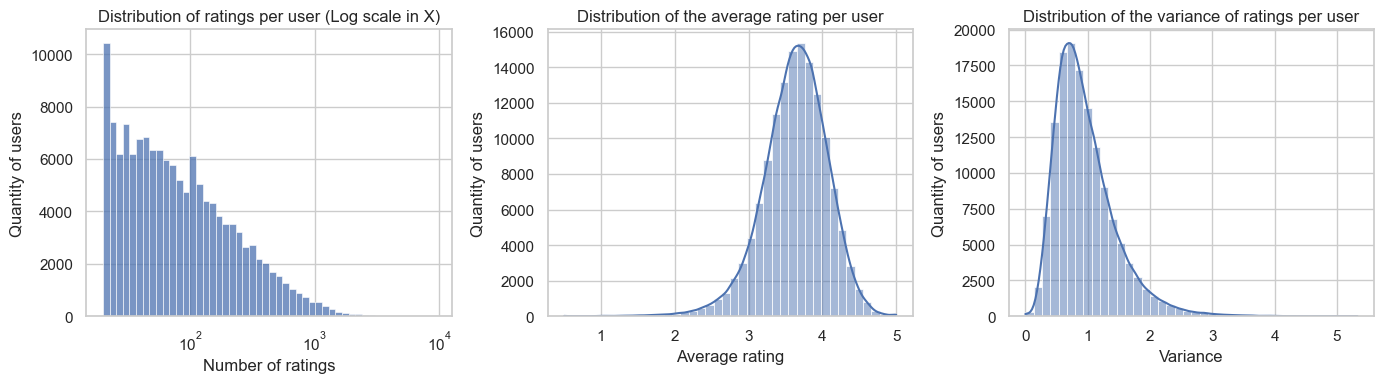

In [32]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

sns.histplot(user_stats["count"], bins=50, log_scale=(True, False), ax=axes[0])
axes[0].set_title("Distribution of ratings per user (Log scale in X)")
axes[0].set_xlabel("Number of ratings")
axes[0].set_ylabel("Quantity of users")

sns.histplot(user_stats["mean"], bins=40, kde=True, ax=axes[1])
axes[1].set_title("Distribution of the average rating per user")
axes[1].set_xlabel("Average rating")
axes[1].set_ylabel("Quantity of users")

sns.histplot(user_stats["var"].dropna(), bins=40, kde=True, ax=axes[2])
axes[2].set_title("Distribution of the variance of ratings per user")
axes[2].set_xlabel("Variance")
axes[2].set_ylabel("Quantity of users")

plt.tight_layout()
plt.show()

   userId  count      mean       var
0       1    175  3.742857  0.146141
1       2     61  4.000000  1.133333
2       3    187  4.122994  0.828877
3       4     28  3.571429  0.624339
4       5     66  4.272727  0.939860


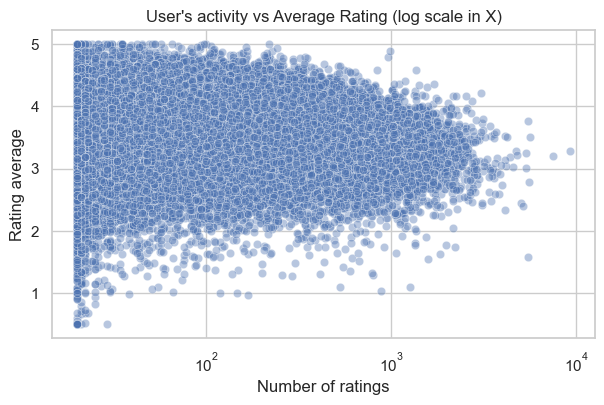

In [33]:
# Relation between user activity and average rating
# Do more active users tend to give higher or lower average ratings?

user_stats = ratings.groupby("userId")["rating"].agg(["count", "mean", "var"]).reset_index()
print(user_stats.head())

plt.figure(figsize=(7,4))
sns.scatterplot(data=user_stats, x="count", y="mean", alpha=0.4)
plt.xscale("log")
plt.title("User's activity vs Average Rating (log scale in X)")
plt.xlabel("Number of ratings")
plt.ylabel("Rating average")
plt.show()

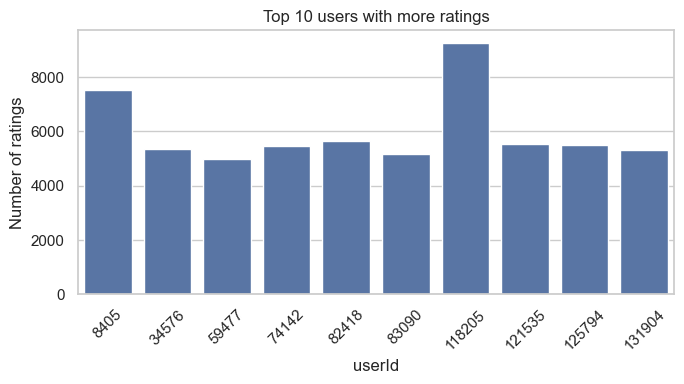

In [34]:
# Users with more ratings

plt.figure(figsize=(7,4))
ax = sns.barplot(data=top_users, x="userId", y="count")

ax.set_title("Top 10 users with more ratings")
ax.set_xlabel("userId")
ax.set_ylabel("Number of ratings")
ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

La actividad de los usuarios presenta una distribución de cola larga. Aunque el promedio es de 144.4 ratings por usuario, la mediana es de 68, lo que indica que la mayoría de los usuarios tiene una actividad moderada y que unos pocos usuarios extremadamente activos elevan la media. Esto se confirma con un máximo de 9254 ratings.

El promedio de rating por usuario está centrado en valores relativamente altos, con media de 3.63 y mediana de 3.65, lo que evidencia un sesgo positivo en la forma en que los usuarios utilizan la escala de calificación. Por su parte, la varianza promedio de 0.96 sugiere que los usuarios sí presentan dispersión en sus evaluaciones, aunque en general sus ratings se mantienen dentro de un rango relativamente consistente.

La relación entre actividad y promedio de rating muestra que los usuarios con pocas interacciones presentan promedios mucho más variables, mientras que los usuarios más activos tienden a estabilizar su media alrededor de valores intermedios-altos. En términos de recomendación, esto indica que el dataset ofrece suficiente señal para filtrado colaborativo, pero también sugiere la conveniencia de considerar normalización o sesgos por usuario, así como prestar atención a la diferencia entre usuarios altamente activos y usuarios con actividad limitada.

##### Análisis de ítems
* ¿Cómo es la distribución del número de ratings por ítem?
* ¿Cómo es la distribución del promedio de calificación por ítem?
* ¿Cómo se comporta la varianza por ítem?
* ¿Cuáles son los ítems con más ratings?

In [35]:
item_stats = ratings.groupby("movieId")["rating"].agg(["count", "mean", "var"]).reset_index()
item_stats = item_stats.merge(movies[["movieId", "title"]], on="movieId", how="left")
top_items = item_stats.sort_values("count", ascending=False).head(10)

print("Distribution of ratings per item:")
print(item_stats["count"].describe())

print("Distribution of the average rating per item:")
print(item_stats["mean"].describe())

print("Distribution of the variance of ratings per item:")
print(item_stats["var"].dropna().describe())

Distribution of ratings per item:
count    26744.000000
mean       747.841123
std       3085.818268
min          1.000000
25%          3.000000
50%         18.000000
75%        205.000000
max      67310.000000
Name: count, dtype: float64
Distribution of the average rating per item:
count    26744.000000
mean         3.133200
std          0.664084
min          0.500000
25%          2.800000
50%          3.235294
75%          3.565217
max          5.000000
Name: mean, dtype: float64
Distribution of the variance of ratings per item:
count    22772.000000
mean         0.946540
std          0.650142
min          0.000000
25%          0.607546
50%          0.875000
75%          1.144425
max         10.125000
Name: var, dtype: float64


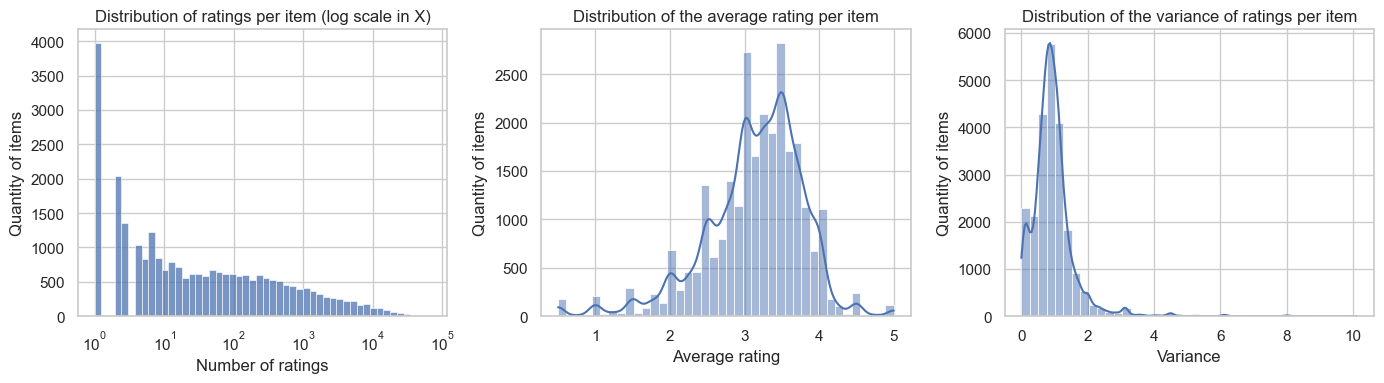

In [36]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

sns.histplot(item_stats["count"], bins=50, log_scale=(True, False), ax=axes[0])
axes[0].set_title("Distribution of ratings per item (log scale in X)")
axes[0].set_xlabel("Number of ratings")
axes[0].set_ylabel("Quantity of items")

sns.histplot(item_stats["mean"], bins=40, kde=True, ax=axes[1])
axes[1].set_title("Distribution of the average rating per item")
axes[1].set_xlabel("Average rating")
axes[1].set_ylabel("Quantity of items")

sns.histplot(item_stats["var"].dropna(), bins=40, kde=True, ax=axes[2])
axes[2].set_title("Distribution of the variance of ratings per item")
axes[2].set_xlabel("Variance")
axes[2].set_ylabel("Quantity of items")

plt.tight_layout()
plt.show()

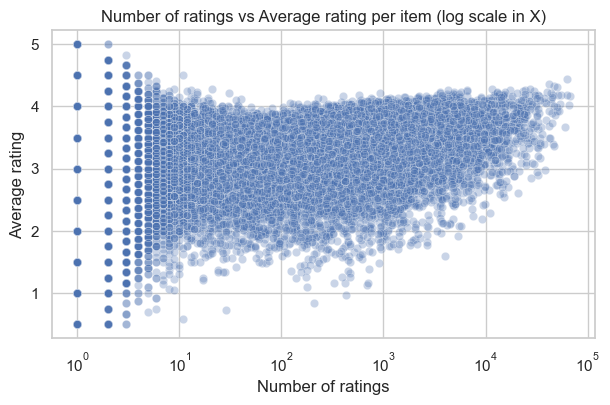

In [37]:
# Relation between number of ratings and average rating per item
# Do movies with more ratings tend to have higher or lower average ratings?

item_stats = ratings.groupby("movieId")["rating"].agg(["count", "mean", "var"]).reset_index()
item_stats.head()

plt.figure(figsize=(7,4))
sns.scatterplot(data=item_stats, x="count", y="mean", alpha=0.3)
plt.xscale("log")
plt.title("Number of ratings vs Average rating per item (log scale in X)")
plt.xlabel("Number of ratings")
plt.ylabel("Average rating")
plt.show()

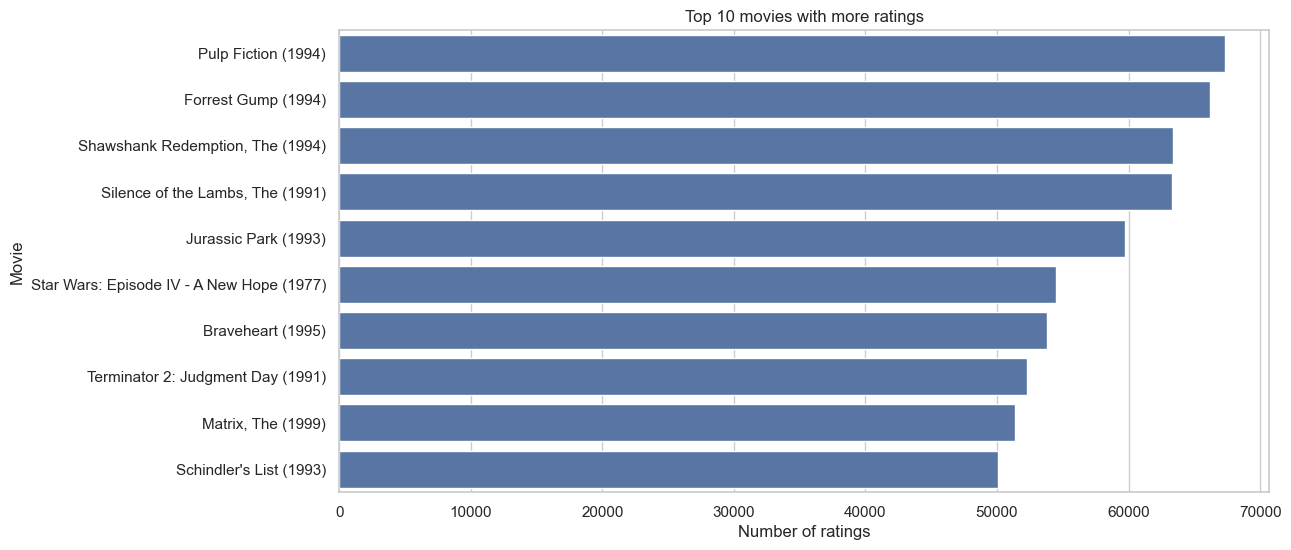

In [38]:
# Items with more ratings

top_items = ratings.groupby("movieId").agg(
    n_ratings=("rating", "count"),
    mean_rating=("rating", "mean"),
    var_rating=("rating", "var")
).reset_index()

top_items = top_items.merge(movies, on="movieId", how="left")
top_items = top_items.sort_values("n_ratings", ascending=False).head(10)

plt.figure(figsize=(12,6))
sns.barplot(data=top_items.head(10), y="title", x="n_ratings")
plt.title("Top 10 movies with more ratings")
plt.xlabel("Number of ratings")
plt.ylabel("Movie")
plt.show()

La distribución del número de ratings por ítem presenta una cola larga muy marcada. Aunque el promedio es de 747.8 ratings por película, la mediana es de apenas 18, lo que indica que la mayoría de las películas recibe pocas interacciones, mientras que un pequeño grupo concentra una gran cantidad de ratings. Esto se confirma con un máximo de 67,310 calificaciones.

El top 10 de películas con más ratings está compuesto por títulos ampliamente conocidos, lo que evidencia una fuerte concentración de la actividad en ítems populares. Esto sugiere que la popularidad tendrá un papel importante en cualquier modelo colaborativo entrenado sobre el dataset.

En cuanto al promedio de rating por ítem, la media es 3.13 y la mediana 3.24, lo que muestra que las películas se ubican en promedio en la zona media de la escala. Sin embargo, la relación entre número de ratings y promedio por ítem indica que los ítems con pocas observaciones presentan valores medios mucho más extremos e inestables, mientras que los ítems populares se concentran en un rango más estrecho. Esto implica que el promedio por sí solo no es una medida suficiente de calidad o preferencia, y debe interpretarse junto con el volumen de ratings.

Finalmente, la varianza promedio por ítem es 0.95, lo que indica una dispersión moderada en las evaluaciones y sugiere que existen películas más polarizantes que otras. En conjunto, este bloque de análisis confirma que el dataset presenta una fuerte cola larga y una alta concentración de interacciones en pocos ítems, lo cual tendrá un impacto directo en el comportamiento del modelo de recomendación.

##### Sparcity y Cola larga

* ¿Qué tan dispersa es la matriz usuario–ítem?
* ¿Existe una cola larga clara?
* ¿Qué porcentaje de ratings se concentra en pocos ítems?

In [39]:
# Density of matrix user-item
# How spread are the ratings in the user-item matrix?

n_users = ratings["userId"].nunique()
n_items = ratings["movieId"].nunique()
n_interactions = len(ratings)

density = n_interactions / (n_users * n_items)

print("Users:", n_users)
print("Items:", n_items)
print("Interactions", n_interactions)
print("Density of the matrix:", density)
print("Sparsity:", 1 - density)

Users: 138493
Items: 26744
Interactions 20000263
Density of the matrix: 0.0053998478135544505
Sparsity: 0.9946001521864456


In [40]:
# What ratings percentage is concentrated in few items?
item_popularity = ratings.groupby("movieId").size().sort_values(ascending=False)
cum_popularity = item_popularity.cumsum() / item_popularity.sum()

top_10_items_share = item_popularity.head(10).sum() / item_popularity.sum()
top_1pct_items = max(1, int(len(item_popularity) * 0.01))
top_10pct_items = max(1, int(len(item_popularity) * 0.10))

share_1pct = item_popularity.head(top_1pct_items).sum() / item_popularity.sum()
share_10pct = item_popularity.head(top_10pct_items).sum() / item_popularity.sum()

print("% ratings in top 10 items:", round(top_10_items_share * 100, 2))
print("% ratings in top 1% items:", round(share_1pct * 100, 2))
print("% ratings in top 10% items:", round(share_10pct * 100, 2))

% ratings in top 10 items: 2.91
% ratings in top 1% items: 33.48
% ratings in top 10% items: 86.05


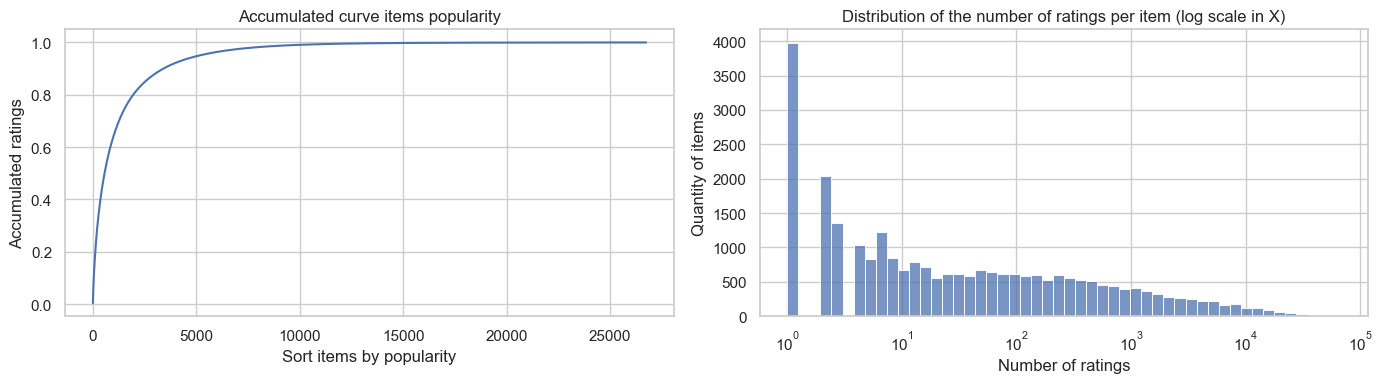

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(np.arange(1, len(cum_popularity) + 1), cum_popularity.values)
axes[0].set_title("Accumulated curve items popularity")
axes[0].set_xlabel("Sort items by popularity")
axes[0].set_ylabel("Accumulated ratings")

sns.histplot(item_popularity, bins=50, log_scale=(True, False), ax=axes[1])
axes[1].set_title("Distribution of the number of ratings per item (log scale in X)")
axes[1].set_xlabel("Number of ratings")
axes[1].set_ylabel("Quantity of items")

plt.tight_layout()
plt.show()

La matriz usuario–ítem del dataset tiene una densidad de 0.0054, lo que equivale a una sparsity de 99.46%. Esto indica que, aunque el volumen total de interacciones es alto, la fracción observada del espacio completo usuario–película sigue siendo muy pequeña. En consecuencia, el problema de recomendación debe abordarse como un escenario altamente disperso, donde el solapamiento entre usuarios o ítems puede ser limitado.

Adicionalmente, el dataset presenta una fuerte cola larga. El top 10 de ítems concentra 2.91% de todos los ratings, el top 1% concentra 33.48% y el top 10% concentra 86.05%. Esto evidencia una gran concentración de interacciones en una fracción pequeña del catálogo, mientras que la mayoría de las películas recibe muy poca actividad.

La curva acumulada de popularidad y el histograma en escala logarítmica confirman este patrón. Desde el punto de vista del filtrado colaborativo, esto implica que los modelos tenderán a funcionar mejor sobre ítems populares, mientras que la cobertura y la calidad de recomendación sobre la cola larga serán más difíciles de lograr. Por tanto, además de las métricas de precisión, será importante considerar el efecto de la popularidad y la cobertura del catálogo en etapas posteriores del taller.

##### Géneros y Tiempo

* ¿Qué géneros dominan el dataset?
* ¿Cómo evoluciona la actividad en el tiempo?

   movieId             title     genres
0        1  Toy Story (1995)  Adventure
0        1  Toy Story (1995)  Animation
0        1  Toy Story (1995)   Children
0        1  Toy Story (1995)     Comedy
0        1  Toy Story (1995)    Fantasy


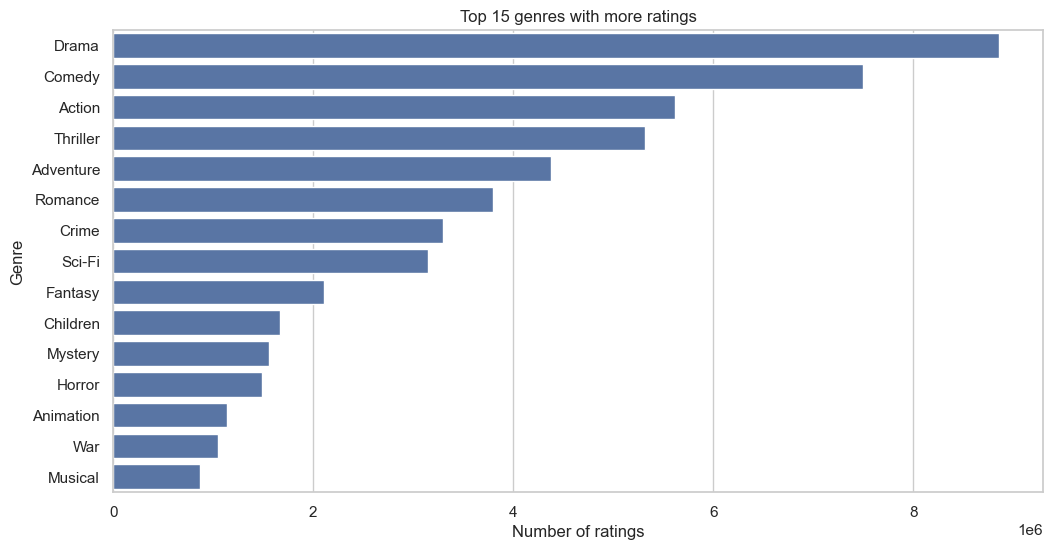

In [42]:
# Popularity by genre
# What genres tend to receive more ratings on average?

movies_genres = movies.copy()
movies_genres["genres"] = movies_genres["genres"].fillna("(no genres listed)")
movies_genres = movies_genres.assign(genres=movies_genres["genres"].str.split("|")).explode("genres")
print(movies_genres.head())

genre_stats = ratings.merge(movies_genres, on="movieId", how="left")
genre_summary = genre_stats.groupby("genres").agg(
    n_ratings=("rating", "count"),
    mean_rating=("rating", "mean"),
    n_movies=("movieId", "nunique")
).reset_index().sort_values("n_ratings", ascending=False)

genre_summary.head(15)

plt.figure(figsize=(12,6))
sns.barplot(data=genre_summary.head(15), y="genres", x="n_ratings")
plt.title("Top 15 genres with more ratings")
plt.xlabel("Number of ratings")
plt.ylabel("Genre")
plt.show()

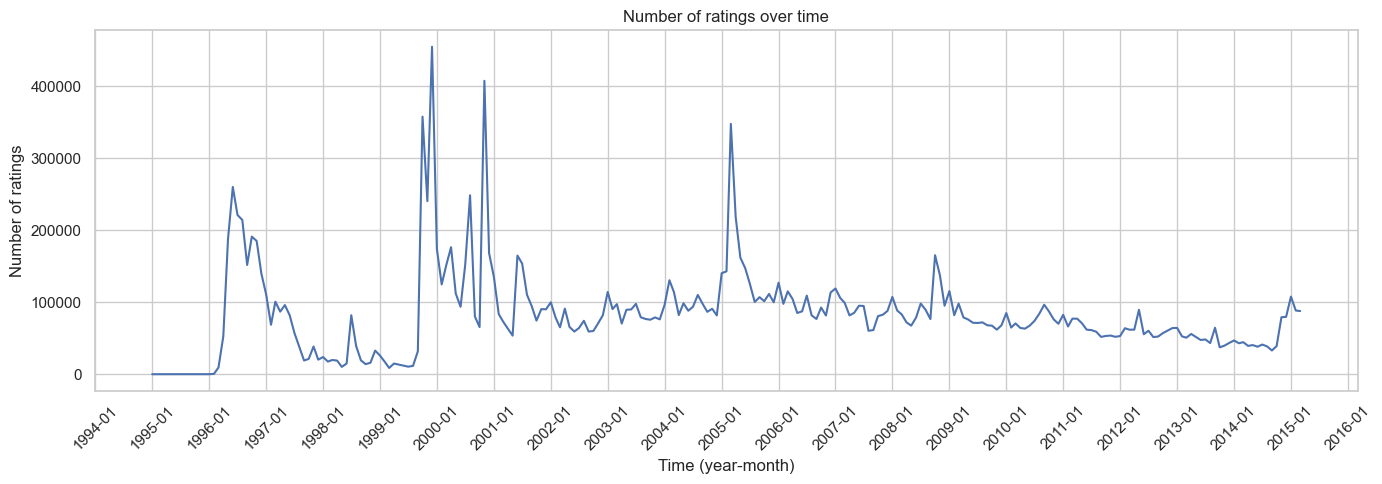

In [43]:
# Temporal patterns in ratings
ratings["year_month"] = ratings["timestamp"].dt.to_period("M").astype(str)
ratings_by_month = ratings.groupby("year_month").size().reset_index(name="n_ratings")
ratings_by_month.tail()

import matplotlib.dates as mdates

# Convert year_month to datetime
ratings_by_month = ratings_by_month.copy()
ratings_by_month["year_month"] = pd.to_datetime(ratings_by_month["year_month"])

plt.figure(figsize=(14, 5))
plt.plot(ratings_by_month["year_month"], ratings_by_month["n_ratings"], linewidth=1.5)

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.YearLocator())          # one tick per year
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
plt.xticks(rotation=45)

plt.title("Number of ratings over time")
plt.xlabel("Time (year-month)")
plt.ylabel("Number of ratings")
plt.tight_layout()
plt.show()

In [44]:
# Never rated movies

movies_without_ratings = movies.loc[~movies["movieId"].isin(ratings["movieId"])]
print("Movies without ratings", len(movies_without_ratings))
movies_without_ratings.head()

Movies without ratings 534


,movieId,title,genres
8555,26018,Chase a Crooked Shadow (1958),Crime|Film-Noir|Mystery|Thriller
8933,26580,"Park Is Mine, The (1986)",Action|Drama|Thriller
9249,27249,"Trumpet of the Swan, The (2001)",Animation|Drama|Musical
9315,27396,"Gentleman's Game, A (2002)",Drama
9770,31797,White Banners (1938),Drama


## 2. Pre-procesamiento de datos

### 2.1 Transforme los datos correspondientes a la interacción entre usuarios e ítems, implementando una estrategia para convertir estos datos en unos que sean compatibles con los modelos vistos en clase. Justifique en el informe sus decisiones en este paso.

#### Dataset base para recomendación

Utilizar solo con las columnas necesarias para modelado colaborativo.

In [6]:
# Base dataset for collaborative filtering
ratings_cf = ratings[["userId", "movieId", "rating", "timestamp"]].copy()

print("Shape:", ratings_cf.shape)
display(ratings_cf.head())
print(ratings_cf.dtypes)

Shape: (20000263, 4)


,userId,movieId,rating,timestamp
0,1,2,3.5,2005-04-02 23:53:47
1,1,29,3.5,2005-04-02 23:31:16
2,1,32,3.5,2005-04-02 23:33:39
3,1,47,3.5,2005-04-02 23:32:07
4,1,50,3.5,2005-04-02 23:29:40


userId                int32
movieId               int32
rating              float32
timestamp    datetime64[us]
dtype: object


#### Representación explícita para Cosine y Pearson

Conservar ratings originales para similitud basada en magnitud y correlación.

In [7]:
# Explicit-feedback dataset
ratings_explicit = ratings_cf.copy()

print("Explicit dataset shape:", ratings_explicit.shape)
display(ratings_explicit.head())

Explicit dataset shape: (20000263, 4)


,userId,movieId,rating,timestamp
0,1,2,3.5,2005-04-02 23:53:47
1,1,29,3.5,2005-04-02 23:31:16
2,1,32,3.5,2005-04-02 23:33:39
3,1,47,3.5,2005-04-02 23:32:07
4,1,50,3.5,2005-04-02 23:29:40


In [8]:
# Quick validation
print("Unique users:", ratings_explicit["userId"].nunique())
print("Unique items:", ratings_explicit["movieId"].nunique())
print("Rating range:", ratings_explicit["rating"].min(), "to", ratings_explicit["rating"].max())
print("Duplicates userId-movieId:", ratings_explicit.duplicated(subset=["userId", "movieId"]).sum())

Unique users: 138493
Unique items: 26744
Rating range: 0.5 to 5.0
Duplicates userId-movieId: 0


#### Representación binaria para Jaccard

Transformar rating explícito en señal binaria de relevancia.

$\text{relevant} = \begin{cases} 1 & \text{si } \text{rating} \ge 3.5 \\ 0 & \text{si } \text{rating} < 3.5 \end{cases}$

In [9]:
# Binary relevance dataset for Jaccard
ratings_binary = ratings_cf[["userId", "movieId", "rating"]].copy()
ratings_binary["relevant"] = (ratings_binary["rating"] >= 3.5).astype("int8")

print("Binary dataset shape:", ratings_binary.shape)
display(ratings_binary.head())

Binary dataset shape: (20000263, 4)


,userId,movieId,rating,relevant
0,1,2,3.5,1
1,1,29,3.5,1
2,1,32,3.5,1
3,1,47,3.5,1
4,1,50,3.5,1


In [10]:
binary_dist = ratings_binary["relevant"].value_counts().sort_index()
binary_pct = ratings_binary["relevant"].value_counts(normalize=True).sort_index() * 100

display(pd.DataFrame({
    "count": binary_dist,
    "pct": binary_pct.round(2)
}))

,count,pct
relevant,,
0,7804697,39.02
1,12195566,60.98


In [11]:
# Set of relevant interactions
ratings_binary_positive = ratings_binary.loc[ratings_binary["relevant"] == 1, ["userId", "movieId"]].copy()

print("Relevant-only shape:", ratings_binary_positive.shape)
display(ratings_binary_positive.head())

Relevant-only shape: (12195566, 2)


,userId,movieId
0,1,2
1,1,29
2,1,32
3,1,47
4,1,50


#### Validaciones del preprocesamiento

* ¿Se preservó el volumen?
* ¿La binarización tiene sentido?
* ¿Quedó todo listo para los tres modelos?

In [52]:
print("Original interactions:", len(ratings_cf))
print("Explicit interactions:", len(ratings_explicit))
print("Binary interactions:", len(ratings_binary))
print("Relevant interactions:", len(ratings_binary_positive))
print()

print("Users in explicit:", ratings_explicit["userId"].nunique())
print("Users in binary:", ratings_binary["userId"].nunique())
print("Users with at least one relevant item:", ratings_binary_positive["userId"].nunique())
print()

print("Items in explicit:", ratings_explicit["movieId"].nunique())
print("Items in binary:", ratings_binary["movieId"].nunique())
print("Items with at least one relevant interaction:", ratings_binary_positive["movieId"].nunique())

Original interactions: 20000263
Explicit interactions: 20000263
Binary interactions: 20000263
Relevant interactions: 12195566

Users in explicit: 138493
Users in binary: 138493
Users with at least one relevant item: 138362

Items in explicit: 26744
Items in binary: 26744
Items with at least one relevant interaction: 22884


#### Guardado de archivos procesados

Facilitar el paso 2.2, Parquet por eficiencia

In [12]:
output_dir = Path("./processed")
output_dir.mkdir(parents=True, exist_ok=True)

ratings_explicit.to_parquet(output_dir / "ratings_explicit.parquet", index=False, engine="fastparquet")
ratings_binary.to_parquet(output_dir / "ratings_binary.parquet", index=False, engine="fastparquet")
ratings_binary_positive.to_parquet(output_dir / "ratings_binary_positive.parquet", index=False, engine="fastparquet")

print("Processed files saved in:", output_dir.resolve())

Processed files saved in: /Users/bryan.guzman/Documents/Personal/Universidad/2026-01/Sistemas de Recomendación/SR-UNIANDES/Talleres/Taller 1/processed


**Decisiones de preprocesamiento**

* Se seleccionó rating.csv como fuente principal de interacción usuario–ítem, porque contiene la señal explícita de preferencia.
* Se conservaron dos representaciones:
* una explícita con ratings originales, adecuada para modelos basados en coseno y Pearson
* una binaria para representar relevancia, adecuada para el índice de Jaccard
* La binarización se hizo con umbral 3.5, porque coincide con la mediana del dataset y está muy cerca de la media global, lo que la hace una frontera razonable entre evaluación favorable y no favorable.
* No se construyó una matriz densa completa usuario–ítem, porque el problema es altamente disperso y esa estrategia sería ineficiente en memoria.
* Se generaron estructuras auxiliares tipo diccionario y conjuntos, más adecuadas para calcular similitudes entre perfiles de usuario en un esquema colaborativo.

### 2.2. Tome los datos compatibles con modelos colaborativos y pártalos en dos conjuntos: un grupo de datos le sirve para construir el modelo y el resto para evaluar sus predicciones. Sepárelos en archivos distintos

#### Definir la estrategia de partición

Partir las interacciones por usuario, ordenadas por tiempo, para que:
* Las más antiguas queden en train
* Las más recientes queden en test
Esto evita fuga de información y simula mejor un escenario real.

In [13]:
TEST_RATIO = 0.2
MIN_TRAIN_INTERACTIONS = 5
MIN_TEST_INTERACTIONS = 1

# SAMPLING PARAMETERS
USER_SAMPLE_RATIOS = [0.2, 0.3, 0.4]
RANDOM_STATE = 42
N_ACTIVITY_STRATA = 5

**Justificación metodológica**

* El dataset es altamente heterogéneo en actividad
* El muestreo estratificado preserva mejor esa heterogeneidad
* El split temporal evita fuga de información

Validar que la muestra sea representativa comparando:

* Distribución de ratings por usuario
* Promedio de rating por usuario
* Proporción de ratings positivos
* Sparsity aproximada entre dataset completo y muestra.

In [14]:
# Build a user activity table for stratified sampling
user_activity = (
    ratings_explicit
    .groupby("userId")
    .size()
    .reset_index(name="n_ratings")
)

user_activity["activity_stratum"] = pd.qcut(
    user_activity["n_ratings"],
    q=N_ACTIVITY_STRATA,
    labels=False,
    duplicates="drop"
)

print(user_activity.head())
print(user_activity["activity_stratum"].value_counts().sort_index())

   userId  n_ratings  activity_stratum
0       1        175                 3
1       2         61                 2
2       3        187                 3
3       4         28                 0
4       5         66                 2
activity_stratum
0    27878
1    27638
2    28004
3    27347
4    27626
Name: count, dtype: int64


In [15]:
def sample_users_stratified(user_activity_df, sample_ratio=0.3, random_state=42):
    """
    Stratified sampling of users based on activity level.
    Keeps the same proportion of users from each activity stratum.
    """
    sampled_users = (
        user_activity_df
        .groupby("activity_stratum", group_keys=False)
        .apply(
            lambda x: x.sample(
                frac=sample_ratio,
                random_state=random_state
            )
        )
        .reset_index(drop=True)
    )
    return sampled_users["userId"].tolist()

In [16]:
def build_sampled_temporal_split(
    ratings_explicit,
    sample_ratio=0.3,
    test_ratio=0.2,
    min_train=5,
    min_test=1,
    random_state=42
):
    """
    1) Sample users stratified by activity
    2) Keep all interactions from sampled users
    3) Split each sampled user's interactions temporally into train/test
    4) Derive binary datasets from explicit train/test
    """
    # user activity table
    user_activity = (
        ratings_explicit
        .groupby("userId")
        .size()
        .reset_index(name="n_ratings")
    )

    user_activity["activity_stratum"] = pd.qcut(
        user_activity["n_ratings"],
        q=N_ACTIVITY_STRATA,
        labels=False,
        duplicates="drop"
    )

    sampled_user_ids = sample_users_stratified(
        user_activity,
        sample_ratio=sample_ratio,
        random_state=random_state
    )

    ratings_explicit_sample = ratings_explicit[
        ratings_explicit["userId"].isin(sampled_user_ids)
    ].copy()

    ratings_explicit_sorted = ratings_explicit_sample.sort_values(
        ["userId", "timestamp"]
    ).copy()

    ratings_explicit_split = (
        ratings_explicit_sorted
        .groupby("userId", group_keys=False)
        .apply(
            temporal_user_split,
            test_ratio=test_ratio,
            min_train=min_train,
            min_test=min_test
        )
        .reset_index(drop=True)
    )

    ratings_explicit_train = ratings_explicit_split.loc[
        ratings_explicit_split["split"] == "train",
        ["userId", "movieId", "rating", "timestamp"]
    ].copy()

    ratings_explicit_test = ratings_explicit_split.loc[
        ratings_explicit_split["split"] == "test",
        ["userId", "movieId", "rating", "timestamp"]
    ].copy()

    ratings_binary_train = ratings_explicit_train[["userId", "movieId", "rating"]].copy()
    ratings_binary_train["relevant"] = (ratings_binary_train["rating"] >= 3.5).astype("int8")

    ratings_binary_test = ratings_explicit_test[["userId", "movieId", "rating"]].copy()
    ratings_binary_test["relevant"] = (ratings_binary_test["rating"] >= 3.5).astype("int8")

    ratings_binary_positive_train = ratings_binary_train.loc[
        ratings_binary_train["relevant"] == 1,
        ["userId", "movieId"]
    ].copy()

    ratings_binary_positive_test = ratings_binary_test.loc[
        ratings_binary_test["relevant"] == 1,
        ["userId", "movieId"]
    ].copy()

    return {
        "sampled_user_ids": sampled_user_ids,
        "ratings_explicit_sample": ratings_explicit_sample,
        "ratings_explicit_train": ratings_explicit_train,
        "ratings_explicit_test": ratings_explicit_test,
        "ratings_binary_train": ratings_binary_train,
        "ratings_binary_test": ratings_binary_test,
        "ratings_binary_positive_train": ratings_binary_positive_train,
        "ratings_binary_positive_test": ratings_binary_positive_test,
    }

In [17]:
def temporal_user_split(group, test_ratio=0.2, min_train=5, min_test=1):
    """
    Split one user's interactions into train/test using temporal order.
    Oldest interactions go to train, newest to test.
    """
    user_id = group.name
    group = group.sort_values("timestamp").copy()
    n = len(group)

    test_size = max(min_test, int(np.ceil(n * test_ratio)))
    train_size = n - test_size

    if train_size < min_train:
        train_size = min_train
        test_size = n - train_size

    if test_size < min_test:
        test_size = min_test
        train_size = n - test_size

    train = group.iloc[:train_size].copy()
    test = group.iloc[train_size:].copy()

    train["split"] = "train"
    test["split"] = "test"

    # Ensure userId is explicitly preserved as a column
    train["userId"] = user_id
    test["userId"] = user_id

    return pd.concat([train, test], axis=0)

In [18]:
# Generate 3 samples with different ratios to test the effect of sample size on model performance and computational efficiency.
sample_splits = {}

for sample_ratio in USER_SAMPLE_RATIOS:
    sample_key = f"{int(sample_ratio * 100)}pct"
    sample_splits[sample_key] = build_sampled_temporal_split(
        ratings_explicit=ratings_explicit,
        sample_ratio=sample_ratio,
        test_ratio=TEST_RATIO,
        min_train=MIN_TRAIN_INTERACTIONS,
        min_test=MIN_TEST_INTERACTIONS,
        random_state=RANDOM_STATE
    )

print(sample_splits.keys())

dict_keys(['20pct', '30pct', '40pct'])


In [24]:
# Inspect sizes of the samples
sample_summary = []

for sample_key, split_data in sample_splits.items():
    sample_summary.append({
        "sample": sample_key,
        "n_users": split_data["ratings_explicit_sample"]["userId"].nunique(),
        "n_items": split_data["ratings_explicit_sample"]["movieId"].nunique(),
        "n_interactions": len(split_data["ratings_explicit_sample"]),
        "n_train": len(split_data["ratings_explicit_train"]),
        "n_test": len(split_data["ratings_explicit_test"]),
        "n_binary_positive_train": len(split_data["ratings_binary_positive_train"]),
        "n_binary_positive_test": len(split_data["ratings_binary_positive_test"]),
    })

sample_summary_df = pd.DataFrame(sample_summary)
display(sample_summary_df)

,sample,n_users,n_items,n_interactions,n_train,n_test,n_binary_positive_train,n_binary_positive_test
0,20pct,27699,20772,3978677,3172052,806625,1947182,483781
1,30pct,41547,22048,5968078,4758143,1209935,2910682,724107
2,40pct,55397,22935,7982998,6364646,1618352,3894783,967352


In [25]:
# Validate representativity in the samples
full_user_stats = ratings_explicit.groupby("userId")["rating"].agg(["count", "mean"]).reset_index()

representativeness_summary = []

for sample_key, split_data in sample_splits.items():
    sample_user_stats = (
        split_data["ratings_explicit_sample"]
        .groupby("userId")["rating"]
        .agg(["count", "mean"])
        .reset_index()
    )

    representativeness_summary.append({
        "sample": sample_key,
        "users": sample_user_stats["count"].count(),
        "mean_ratings_per_user": sample_user_stats["count"].mean(),
        "median_ratings_per_user": sample_user_stats["count"].median(),
        "mean_user_rating": sample_user_stats["mean"].mean(),
        "median_user_rating": sample_user_stats["mean"].median(),
    })

representativeness_df = pd.DataFrame(representativeness_summary)
display(representativeness_df)

print("Full dataset reference:")
print("Mean ratings per user:", full_user_stats["count"].mean())
print("Median ratings per user:", full_user_stats["count"].median())
print("Mean user rating:", full_user_stats["mean"].mean())
print("Median user rating:", full_user_stats["mean"].median())

,sample,users,mean_ratings_per_user,median_ratings_per_user,mean_user_rating,median_user_rating
0,20pct,27699,143.639734,68.0,3.629397,3.656250
1,30pct,41547,143.646425,68.0,3.629634,3.655738
2,40pct,55397,144.105240,68.0,3.628914,3.655914


Full dataset reference:
Mean ratings per user: 144.4135299257002
Median ratings per user: 68.0
Mean user rating: 3.6272087
Median user rating: 3.6538463


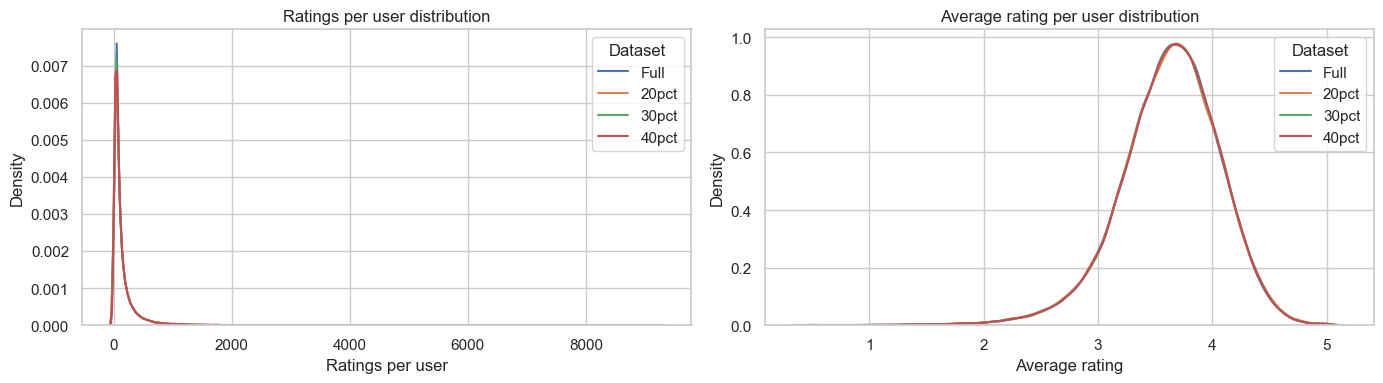

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.kdeplot(full_user_stats["count"], label="Full", ax=axes[0])
for sample_key, split_data in sample_splits.items():
    sample_user_stats = (
        split_data["ratings_explicit_sample"]
        .groupby("userId")["rating"]
        .agg(["count", "mean"])
        .reset_index()
    )
    sns.kdeplot(sample_user_stats["count"], label=sample_key, ax=axes[0])

axes[0].set_title("Ratings per user distribution")
axes[0].set_xlabel("Ratings per user")
axes[0].set_ylabel("Density")
axes[0].legend(title="Dataset")

sns.kdeplot(full_user_stats["mean"], label="Full", ax=axes[1])
for sample_key, split_data in sample_splits.items():
    sample_user_stats = (
        split_data["ratings_explicit_sample"]
        .groupby("userId")["rating"]
        .agg(["count", "mean"])
        .reset_index()
    )
    sns.kdeplot(sample_user_stats["mean"], label=sample_key, ax=axes[1])

axes[1].set_title("Average rating per user distribution")
axes[1].set_xlabel("Average rating")
axes[1].set_ylabel("Density")
axes[1].legend(title="Dataset")

plt.tight_layout()
plt.show()

#### Derivar la versión binaria de train y test

Construir los datasets binarios usando exactamente el mismo split, para no introducir inconsistencias.

In [22]:
# Choose a working sample for the rest of the workshop
WORKING_SAMPLE_KEY = "30pct"

ratings_explicit_train = sample_splits[WORKING_SAMPLE_KEY]["ratings_explicit_train"].copy()
ratings_explicit_test = sample_splits[WORKING_SAMPLE_KEY]["ratings_explicit_test"].copy()

ratings_binary_train = sample_splits[WORKING_SAMPLE_KEY]["ratings_binary_train"].copy()
ratings_binary_test = sample_splits[WORKING_SAMPLE_KEY]["ratings_binary_test"].copy()

ratings_binary_positive_train = sample_splits[WORKING_SAMPLE_KEY]["ratings_binary_positive_train"].copy()
ratings_binary_positive_test = sample_splits[WORKING_SAMPLE_KEY]["ratings_binary_positive_test"].copy()

print("Working sample selected:", WORKING_SAMPLE_KEY)
print("Explicit train shape:", ratings_explicit_train.shape)
print("Explicit test shape:", ratings_explicit_test.shape)

Working sample selected: 30pct
Explicit train shape: (4758143, 4)
Explicit test shape: (1209935, 4)


In [23]:
ratings_binary_train = ratings_explicit_train[["userId", "movieId", "rating"]].copy()
ratings_binary_train["relevant"] = (ratings_binary_train["rating"] >= 3.5).astype("int8")

ratings_binary_test = ratings_explicit_test[["userId", "movieId", "rating"]].copy()
ratings_binary_test["relevant"] = (ratings_binary_test["rating"] >= 3.5).astype("int8")

ratings_binary_positive_train = ratings_binary_train.loc[
    ratings_binary_train["relevant"] == 1,
    ["userId", "movieId"]
].copy()

ratings_binary_positive_test = ratings_binary_test.loc[
    ratings_binary_test["relevant"] == 1,
    ["userId", "movieId"]
].copy()

print("Binary train shape:", ratings_binary_train.shape)
print("Binary test shape:", ratings_binary_test.shape)
print("Positive binary train shape:", ratings_binary_positive_train.shape)
print("Positive binary test shape:", ratings_binary_positive_test.shape)

Binary train shape: (4758143, 4)
Binary test shape: (1209935, 4)
Positive binary train shape: (2910682, 2)
Positive binary test shape: (724107, 2)


#### Validación del split
Asegurarnos de que el split cumple lo que necesitamos para un modelo user-user.

In [24]:
print("Users in train:", ratings_explicit_train["userId"].nunique())
print("Users in test:", ratings_explicit_test["userId"].nunique())

users_train = set(ratings_explicit_train["userId"].unique())
users_test = set(ratings_explicit_test["userId"].unique())

print("Users in test not in train:", len(users_test - users_train))
print("Users in both train and test:", len(users_train & users_test))

Users in train: 41547
Users in test: 41547
Users in test not in train: 0
Users in both train and test: 41547


In [25]:
# Validate there are no overlap between train and test user-item pairs
train_pairs = set(zip(ratings_explicit_train["userId"], ratings_explicit_train["movieId"]))
test_pairs = set(zip(ratings_explicit_test["userId"], ratings_explicit_test["movieId"]))

print("Overlap train-test userId/movieId pairs:", len(train_pairs & test_pairs))

Overlap train-test userId/movieId pairs: 0


In [26]:
# Check min interactions per user
train_counts = ratings_explicit_train.groupby("userId").size()
test_counts = ratings_explicit_test.groupby("userId").size()

print("Train interactions per user - summary:")
print(train_counts.describe())

print("Test interactions per user - summary:")
print(test_counts.describe())

print("Users with train interactions < MIN_TRAIN_INTERACTIONS:", (train_counts < MIN_TRAIN_INTERACTIONS).sum())
print("Users with test interactions < MIN_TEST_INTERACTIONS:", (test_counts < MIN_TEST_INTERACTIONS).sum())

Train interactions per user - summary:
count    41547.000000
mean       114.524346
std        177.131493
min         16.000000
25%         27.000000
50%         54.000000
75%        124.000000
max       3828.000000
dtype: float64
Test interactions per user - summary:
count    41547.000000
mean        29.122079
std         44.284670
min          4.000000
25%          7.000000
50%         14.000000
75%         31.000000
max        957.000000
dtype: float64
Users with train interactions < MIN_TRAIN_INTERACTIONS: 0
Users with test interactions < MIN_TEST_INTERACTIONS: 0


Para separar los datos en entrenamiento y prueba se adoptó una estrategia en dos etapas. Primero, dado el tamaño del dataset y las limitaciones de memoria del entorno de cómputo, se construyeron muestras del 20%, 30% y 40% de los usuarios. En lugar de muestrear interacciones individuales, se decidió muestrear usuarios completos, conservando todas sus interacciones, ya que el modelo a construir es colaborativo basado en perfiles de usuario. Además, el muestreo se realizó de forma estratificada por nivel de actividad, con el fin de preservar la heterogeneidad observada en el dataset entre usuarios poco activos, medianamente activos y altamente activos.

Posteriormente, sobre cada muestra se aplicó una partición temporal por usuario. En esta estrategia, las interacciones de cada usuario se ordenaron cronológicamente y se asignó aproximadamente el 80% más antiguo al conjunto de entrenamiento y el 20% más reciente al conjunto de prueba. Esta decisión permite construir el perfil del usuario con información pasada y evaluar las predicciones sobre interacciones futuras, evitando fuga de información y representando de manera más realista el problema de recomendación.

La representatividad de las muestras se validó comparando su distribución de actividad y sus promedios de rating con respecto al dataset completo. A partir de esta comparación, se seleccionó como muestra de trabajo la del 30% de usuarios, ya que ofrecía un equilibrio adecuado entre representatividad estadística y viabilidad computacional. Sobre esta muestra, la partición resultó consistente: todos los usuarios presentes en prueba también aparecen en entrenamiento, no se detectaron traslapes entre pares usuario--ítem de train y test, y no se encontraron violaciones del orden temporal. Además, cada usuario conservó suficientes interacciones en ambos conjuntos para permitir tanto la construcción del perfil como la evaluación posterior.

A partir de esta partición se derivaron conjuntos compatibles con los distintos modelos colaborativos del taller: una versión explícita para similitudes basadas en coseno y correlación de Pearson, y una versión binaria para el índice de Jaccard. Finalmente, los datasets resultantes se almacenaron en formato Parquet utilizando fastparquet, lo que permitió una persistencia eficiente y reutilizable para las siguientes etapas del taller.

In [27]:
# Validate temporal order
train_last_ts = ratings_explicit_train.groupby("userId")["timestamp"].max()
test_first_ts = ratings_explicit_test.groupby("userId")["timestamp"].min()

temporal_check = pd.concat([train_last_ts, test_first_ts], axis=1)
temporal_check.columns = ["train_last_ts", "test_first_ts"]
temporal_check["valid_temporal_split"] = temporal_check["train_last_ts"] <= temporal_check["test_first_ts"]

display(temporal_check.head())
print("Users with invalid temporal split:", (~temporal_check["valid_temporal_split"]).sum())

,train_last_ts,test_first_ts,valid_temporal_split
userId,,,
13,1996-11-27 08:18:17,1996-11-27 08:18:17,True
15,1996-08-16 15:00:18,1996-08-16 15:00:18,True
20,2005-09-12 15:44:02,2005-09-12 15:44:11,True
21,2001-06-10 16:21:11,2001-06-10 16:21:11,True
24,2001-07-14 07:57:02,2001-07-14 07:57:02,True


Users with invalid temporal split: 0


#### Guardar archivos en disco
Dejar listos los archivos para el punto 3.

In [28]:
output_dir = Path("./processed")
output_dir.mkdir(parents=True, exist_ok=True)

ratings_explicit_train.to_parquet(
    output_dir / f"ratings_explicit_train_{WORKING_SAMPLE_KEY}.parquet",
    index=False,
    engine="fastparquet",
)
ratings_explicit_test.to_parquet(
    output_dir / f"ratings_explicit_test_{WORKING_SAMPLE_KEY}.parquet",
    index=False,
    engine="fastparquet",
)

ratings_binary_train.to_parquet(
    output_dir / f"ratings_binary_train_{WORKING_SAMPLE_KEY}.parquet",
    index=False,
    engine="fastparquet",
)
ratings_binary_test.to_parquet(
    output_dir / f"ratings_binary_test_{WORKING_SAMPLE_KEY}.parquet",
    index=False,
    engine="fastparquet",
)

ratings_binary_positive_train.to_parquet(
    output_dir / f"ratings_binary_positive_train_{WORKING_SAMPLE_KEY}.parquet",
    index=False,
    engine="fastparquet",
)
ratings_binary_positive_test.to_parquet(
    output_dir / f"ratings_binary_positive_test_{WORKING_SAMPLE_KEY}.parquet",
    index=False,
    engine="fastparquet",
)

print("Processed split files saved in:", output_dir.resolve())

Processed split files saved in: /Users/bryan.guzman/Documents/Personal/Universidad/2026-01/Sistemas de Recomendación/SR-UNIANDES/Talleres/Taller 1/processed


**Decisiones de partición**

* Se adoptó una estrategia en dos etapas:
  1. Primero se realizó un muestreo de usuarios sobre el dataset completo, construyendo muestras del 20\%, 30\% y 40\% de usuarios.
  2. Luego, sobre cada muestra, se aplicó una partición temporal por usuario.

* El muestreo se hizo por usuarios completos, no por interacciones individuales, porque el modelo a construir es colaborativo basado en perfiles de usuario y era necesario conservar el historial completo de cada usuario seleccionado.

* Además, el muestreo se realizó de forma estratificada por nivel de actividad, con el fin de preservar la heterogeneidad del dataset entre usuarios poco activos, medianamente activos y altamente activos.

* Tras validar la representatividad de las muestras y considerando las limitaciones de memoria del entorno de cómputo, se seleccionó como muestra de trabajo la del 30\% de usuarios.

* Para cada usuario de la muestra seleccionada:
  * Se ordenaron sus interacciones por `timestamp`
  * El 80\% más antiguo se asignó a `train`
  * El 20\% más reciente se asignó a `test`

**Ventajas**
* El muestreo por usuarios preserva perfiles completos y evita distorsionar la estructura del problema colaborativo
* La estratificación por actividad mantiene una muestra más representativa del dataset original
* La partición temporal evita fuga de información
* Es más realista que un split aleatorio
* Permite construir el perfil del usuario con interacciones pasadas y evaluar sobre interacciones futuras
* Reduce el volumen de datos a un tamaño manejable sin romper la lógica del modelo user-user

**Consistencia con las métricas**
A partir del split explícito se derivaron:
* Una versión explícita para Cosine y Pearson
* Una versión binaria para Jaccard

De esta manera, los tres modelos trabajan sobre exactamente la misma partición base y sobre la misma muestra de usuarios.

## 3. Construcción de modelos colaborativos usuario-usuario

### 3.1. Construya un modelo colaborativo basado en perfiles de usuario con la primera parte de los datos de ratings.

#### Cargar los datasets de entrenamiento
Usar la primera parte de los datos ya separados en train.

In [29]:
# Paths
processed_dir = Path("./processed")
WORKING_SAMPLE_KEY = "30pct"

In [30]:
# Load train datasets
ratings_explicit_train = pd.read_parquet(
    processed_dir / f"ratings_explicit_train_{WORKING_SAMPLE_KEY}.parquet",
    engine="fastparquet"
)

ratings_explicit_test = pd.read_parquet(
    processed_dir / f"ratings_explicit_test_{WORKING_SAMPLE_KEY}.parquet",
    engine="fastparquet"
)

ratings_binary_positive_train = pd.read_parquet(
    processed_dir / f"ratings_binary_positive_train_{WORKING_SAMPLE_KEY}.parquet",
    engine="fastparquet"
)

ratings_binary_positive_test = pd.read_parquet(
    processed_dir / f"ratings_binary_positive_test_{WORKING_SAMPLE_KEY}.parquet",
    engine="fastparquet"
)

print("Explicit train shape:", ratings_explicit_train.shape)
print("Explicit test shape:", ratings_explicit_test.shape)
print("Positive binary train shape:", ratings_binary_positive_train.shape)
print("Positive binary test shape:", ratings_binary_positive_test.shape)

display(ratings_explicit_train.head())
display(ratings_binary_positive_train.head())

Explicit train shape: (4758143, 4)
Explicit test shape: (1209935, 4)
Positive binary train shape: (2910682, 2)
Positive binary test shape: (724107, 2)


,userId,movieId,rating,timestamp
0,13,150,5.0,1996-11-27 08:12:46
1,13,296,5.0,1996-11-27 08:12:46
2,13,380,2.0,1996-11-27 08:12:46
3,13,590,4.0,1996-11-27 08:12:46
4,13,592,3.0,1996-11-27 08:12:46


,userId,movieId
0,13,150
1,13,296
2,13,590
3,13,457
4,13,356


#### Construcción de estructuras para el modelo Jaccard
Representar cada usuario por el conjunto de ítems relevantes que consumió en train.

Esto será la base del modelo user-user con Jaccard.

In [31]:
# Relevant items per user in train
user_items_binary_train = (
    ratings_binary_positive_train
    .groupby("userId")["movieId"]
    .apply(set)
    .to_dict()
)

print("Number of users in user_items_binary_train:", len(user_items_binary_train))
first_user = next(iter(user_items_binary_train))
print("Example user:", first_user)
print("First 10 relevant items:", list(user_items_binary_train[first_user])[:10])

Number of users in user_items_binary_train: 41488
Example user: 13
First 10 relevant items: [266, 11, 527, 150, 32, 161, 160, 292, 420, 296]


In [32]:
# Users per item in train (useful to generate candidate neighbors)
item_users_train = (
    ratings_binary_positive_train
    .groupby("movieId")["userId"]
    .apply(set)
    .to_dict()
)

print("Number of items in item_users_train:", len(item_users_train))
first_item = next(iter(item_users_train))
print("Example item:", first_item)
print("First 10 users:", list(item_users_train[first_item])[:10])

Number of items in item_users_train: 16116
Example item: 1
First 10 users: [131073, 32774, 65542, 98310, 131081, 32780, 65548, 98323, 65557, 65558]


#### Definir la similitud de Jaccard

In [33]:
def jaccard_similarity(user_a_items, user_b_items):
    """
    Compute Jaccard similarity between two sets of relevant items.
    """
    intersection = len(user_a_items & user_b_items)
    union = len(user_a_items | user_b_items)

    if union == 0:
        return 0.0

    return intersection / union

In [34]:
# Quick validation
users_list = list(user_items_binary_train.keys())

if len(users_list) >= 2:
    u1, u2 = users_list[0], users_list[1]
    sim = jaccard_similarity(user_items_binary_train[u1], user_items_binary_train[u2])
    print(f"Jaccard similarity between users {u1} and {u2}: {sim:.4f}")

Jaccard similarity between users 13 and 15: 0.1290


#### Construcción conceptual del modelo Jaccard user-user

Definir el “modelo” base de Jaccard como las estructuras necesarias para comparar perfiles de usuario.
Aquí no hay un .fit() como en Surprise; el modelo queda representado por:

* Perfiles binarios por usuario
* Índice ítem → usuarios
* Función de similitud

In [38]:
import pickle
models_dir = Path("./models")
models_dir.mkdir(parents=True, exist_ok=True)

In [35]:
jaccard_model = {
    "user_items": user_items_binary_train,
    "item_users": item_users_train,
    "similarity_function": jaccard_similarity,
    "model_type": "user-user-jaccard"
}

print("Jaccard model created successfully.")
print("Model type:", jaccard_model["model_type"])

Jaccard model created successfully.
Model type: user-user-jaccard


In [40]:
with open(models_dir / f"jaccard_model_{WORKING_SAMPLE_KEY}.pkl", "wb") as f:
    pickle.dump(jaccard_model, f)

print("Jaccard model saved.")

Jaccard model saved.


#### Cargar datos en surprise

In [ ]:
reader = Reader(rating_scale=(0.5, 5.0))

train_dataset = Dataset.load_from_df(
    ratings_explicit_train[["userId", "movieId", "rating"]],
    reader
)

trainset = train_dataset.build_full_trainset()
print("Surprise trainset built successfully.")

#### Construcción del modelo user-user con Cosine usando Surprise
Entrenar el modelo colaborativo user-user con similitud coseno sobre ratings explícitos.

In [36]:
# Train Cosine model
cosine_sim_options = {
    "name": "cosine",
    "user_based": True
}

cosine_model = KNNBasic(
    k=40,
    min_k=1,
    sim_options=cosine_sim_options,
    verbose=True
)

cosine_model.fit(trainset)
print("Cosine user-user model trained successfully.")

Surprise trainset built successfully.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Cosine user-user model trained successfully.


In [39]:
with open(models_dir / f"cosine_model_{WORKING_SAMPLE_KEY}.pkl", "wb") as f:
    pickle.dump(cosine_model, f)

print("Cosine model saved.")

Cosine model saved.


#### Construcción del modelo user-user con Cosine usando Surprise
Entrenar el modelo colaborativo user-user con correlación de Pearson.
Como Pearson se beneficia de considerar el sesgo del usuario, aquí usaremos KNNWithMeans.

In [42]:
pearson_sim_options = {
    "name": "pearson",
    "user_based": True
}

pearson_model = KNNWithMeans(
    k=40,
    min_k=1,
    sim_options=pearson_sim_options,
    verbose=True
)

pearson_model.fit(trainset)
print("Pearson user-user model trained successfully.")

Computing the pearson similarity matrix...
Done computing similarity matrix.
Pearson user-user model trained successfully.


In [43]:
with open(models_dir / f"pearson_model_{WORKING_SAMPLE_KEY}.pkl", "wb") as f:
    pickle.dump(pearson_model, f)

print("Cosine and Pearson models saved.")

Cosine and Pearson models saved.


### 3.2. Realice las predicciones de relevancia para los usuarios e ítems que encuentra en la segunda parte de los datos

### 3.3. Compare su predicción de rating con el efectivamente encontrado en el dataset. Establezca una forma de evaluar globalmente sus distancias en las predicciones que refleje la calidad de las mismas

### 3.4. Varíe la estrategia de selección de vecinos por umbral de similitud y por número de vecinos. Revise cuál es el impacto al variar estos parámetros

### 3.5 Revise la estrategia de ponderación por significancia de McLaughlin’s [1] (McLaughlin’s significance weighting) y revise cuál es el impacto al variar los parámetros de esta estrategia.